<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi George, my name is Svetlana (https://hub.tripleten.com/u/855fe797). Congratulations on submitting Time Series project! 🎉 Here I will be using the standard color marking:
    

<div style="border: 5px solid green; padding: 15px; margin: 5px">

Great solutions and ideas that can and should be used in the future are in green comments. Some of them are: 
    
    
- You have successfully prepared the subsets. It is important to split the data correctly in order to ensure there's no intersection;    
    
    
- You have successfully investigated the data we have; 
    
    
- It's great that you used `statsmodels` to analyze time series as it provides comprehensive summaries that can be useful when we need to make data-driven decisions;



- Trained and compared several models. It is not enough to just train a model. We also need to analyze the results and compare different models. Very good! 



- Wrote an excellent conclusion! A well-written conclusion shows how the project met its objectives and provides a concise and understandable summary for those who may not have been involved in the details of the project. Good job! 

</div>
    
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Yellow color indicates what should be optimized. This is not necessary, but it will be great if you make changes to this project. I've left several recommendations throughout the project. 
    
</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Issues that must be corrected to achieve accurate results are indicated in red comments. Please note that the project cannot be accepted until these issues are resolved.
    
</div>         
<hr>
    
<font color='dodgerblue'>**To sum up:**</font> thank you very much for submitting the project! You did a fantastic job here. You have successfully trained several models and analyzed time series, which is great! The results are represented and interpreted effectively. However, there're a couple of issues that need your attention. Would you take a look at my comments?
    

<hr>
    
Please use some color other than those listed to highlight answers to my comments.
I would also ask you **not to change, move or delete my comments** to make it easier for me to navigate during the next review.



<hr> 
    
✍️ Some notes: 


- Here's a [link](https://machinelearningmastery.com/autoregression-models-time-series-forecasting-python/) to the article about the autoregression models that you may find interesting. 
    
    
- [Here](https://medium.com/@soumyachess1496/cross-validation-in-time-series-566ae4981ce4) you can read about cross-validation with time series.
    

- Consider using advanced tools such as [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) and [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html). `ColumnTransformer` and `Pipeline` are essential tools that help us create robust, maintainable, and efficient machine learning workflows. They work with data much more effectively. You can handle different data types and it is much easier to avoid data leakage. The code organization is very clean, but it may seem a bit difficult at the beginning. Take a look at this page to learn how to [organize a pipeline with ColumnTransformer](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html).  
<hr>
    

</div>

# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

In [1]:
import time
import pandas as pd
import lightgbm as lgb

from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error


# Phase 0 - Constants, Configs, and Functions

## Constants and Configs

In [2]:
# Standardizes the 'random_state' parameter across project
RNG = 12345

# Standardizes which Scaler to use across project
scaler = StandardScaler()

## Functions

In [3]:
# Function to train and evaluate using the Models
def train_evaluate(model,
                   X_train,
                   X_test,
                   y_train,
                   y_test,
                   verbose=True):
    """
    Train and evaluate a single model.

    Returns:
        pd.DataFrame row with model, model_name, rmse
    """

    # Train Model and Make Predictions
    train_start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - train_start_time

    pred_start_time = time.time()
    predict = model.predict(X_test)
    pred_time = time.time() - pred_start_time

    # Calculate RMSE Metric
    model_rmse = mean_squared_error(y_test, predict) ** 0.5
   

    return{
        'Model': type(model).__name__,
        'RMSE': model_rmse,
        'Train Time': train_time,
        'Pred Time': pred_time
    }

## Step 1.1 - Load & Inspect the Data

In [4]:
# read data file
taxi_data = pd.read_csv(
    "data/taxi.csv",
    index_col=[0],
    parse_dates=[0]
)

taxi_data.info()
print(taxi_data.head(10))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32
2018-03-01 00:50:00          21
2018-03-01 01:00:00           7
2018-03-01 01:10:00           5
2018-03-01 01:20:00          17
2018-03-01 01:30:00          12


## Step 1.3 - Resample by Hour

In [5]:
# resample data by 1 hour
taxi_data.sort_index(inplace=True)
taxi_resampled = taxi_data.resample('1h').sum()

#taxi_resampled.info()
taxi_resampled.describe()
#print(taxi_resampled.head(10))

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
The resampling is correct! We indeed need to use `sum`, not `mean`, since we need to forecast the total number of rides. 
    
</div>

# Phase 2 - Exploratory Data Analysis

## Step 2.1 - Plot the Full Time Series

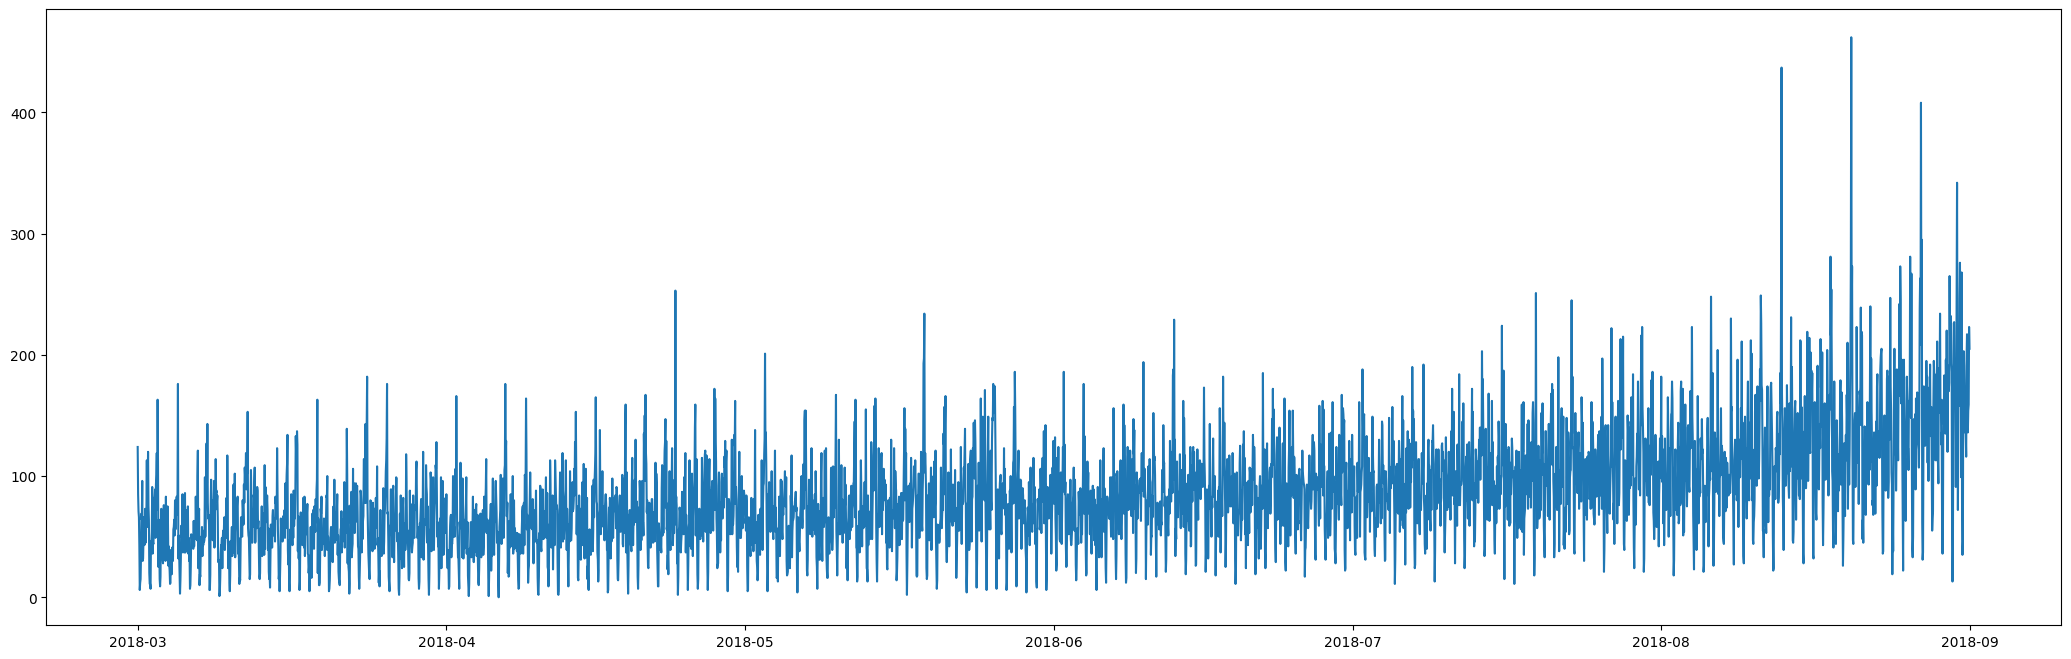

In [6]:
# plot the resampled data to look for trends, seasonality, and anomalies
plt.figure(figsize=(26, 8))
plt.plot(taxi_resampled)
plt.show()


# Analysis of the Resampled Data

1. **The Trend** - for this 6 month batch of data, there is a uptrend. The hourly number of orders for a taxi to and from the airport in March 2018 had a floor of around 20 orders and a ceiling around 150 orders. However, by August 2018, the floor increased to around 50 orders and a ceiling around 200 orders.
2. **The Spikes** - In March 2018, the spikes look random but maybe like once a week (hard to tell with the size of the graph). However, towards the end they look like they are maybe at the end of the week and could be the weekend rush or business trips that are leaving on Monday and returning on Friday.
3. **The Oscillation** - The drop of the number of orders seems to be inline with the overnight drop when people are not traveling from/to the airport.
4. **Anything Suspicious** - the only thing tha seems suspicious is it looks like there is an short term increase towards the end of the data. This seems like it would be due to the Labor Day weekend, which was 1-3 Sept 2018.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
There's indeed a visible trend by months. However, in the future, also check data from other years if the data is available. The sample size here is too small, so we can't draw conclusions on large timeframes. In this case, the increase in orders might simply be due to the business growth: more cars and/or clients -> more orders.


</div>

## Step 2.2 - Decompose the Series

<Figure size 2600x800 with 0 Axes>

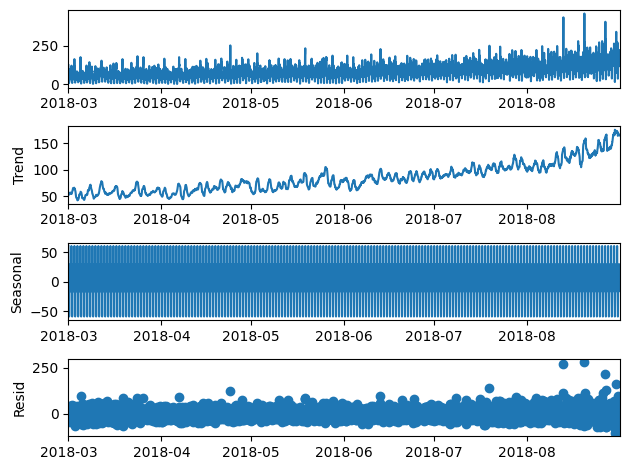

In [7]:
# Decompose using Seasonal_Decompose
decomposed = seasonal_decompose(
                taxi_resampled,
                model= 'additive',
                period= 24,
                extrapolate_trend= 'freq'
            )

plt.figure(figsize=(26, 8))
decomposed.plot()

plt.tight_layout()
plt.show()

## Step 2.3 - Rolling Statistics

<AxesSubplot:xlabel='datetime'>

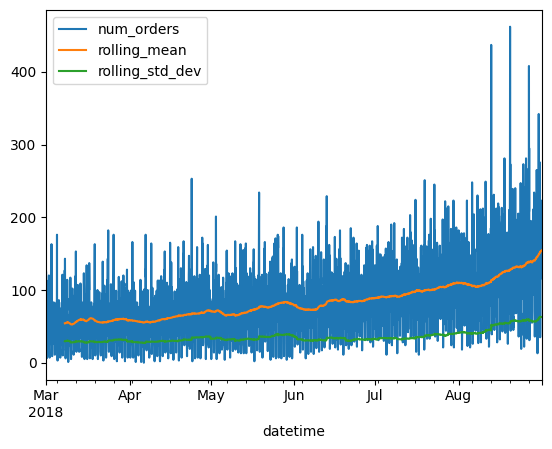

In [8]:
# Analyizing Rolling statistics
taxi_rolling = taxi_resampled.copy()
taxi_rolling['rolling_mean'] = taxi_resampled['num_orders'].rolling(window=168).mean()
taxi_rolling['rolling_std_dev'] = taxi_resampled['num_orders'].rolling(window=168).std()

taxi_rolling.plot()

### Analysis of the Rolling Statistics

The rolling statistics, calculated using a 168-hour (one week) window, 
confirm that this series is **non-stationary**. The rolling mean shows a 
steady upward climb beginning around April 2018, with a more pronounced 
acceleration starting in July 2018 — indicating that the average demand 
level is not stable over time. The rolling standard deviation remains 
relatively flat through mid-July 2018, suggesting stable variance during 
that period. However, from mid-July through August 2018, the standard 
deviation begins to rise, indicating increasing volatility likely driven 
by the sharp trend acceleration and holiday-related demand spikes 
approaching Labor Day weekend. Together, these findings confirm that both 
the mean and variance of the series change over time, which is the 
defining characteristic of a non-stationary time series.


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
`seasonal_decompose` is a great method, well done! 
    
</div>

# Phase 3 - Feature Engineering

### Side thoughts pertaining to Feature Engineering

1. If the "victory" threshold was tighter, I would consider **conditional mean imputation** to handle any `NaN` values that resulted from the `.shift()` for the lag features. The condition would be to take the mean of the same hour on the same day of the week to create a more accurate value to use in replacing the `NaN` value for that given hour. This would allow the model to have a more accurate representation of what happens every hour of every day during this period of time...so that it can utilize that accurate data in its predictions.
2. If this was a live pipeline being built for an actual taxi company, I would also look into adding in the flight schedule data for the given airport. This would allow for a correlation between flight arrivals/departures and the number of taxis ordered.

## Step 3.1 - Lag Features

In [9]:
# Iterate data in 'taxi_features' over 'lag_value' creating columns for lag value list
lag_value = [1, 2, 3, 24, 168]
taxi_lag_features = taxi_resampled.copy()
for value in lag_value:
    shifted = taxi_lag_features['num_orders'].shift(value)
    taxi_lag_features[f'lag_{value}'] = shifted.dropna()

taxi_lag_features.info() 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   num_orders  4416 non-null   int64  
 1   lag_1       4416 non-null   float64
 2   lag_2       4416 non-null   float64
 3   lag_3       4416 non-null   float64
 4   lag_24      4416 non-null   float64
 5   lag_168     4416 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 241.5 KB


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Correct. Sometimes we can notice autocorrelation in time series. It means that the current value of the series depends on the previous values. Including so-called lag components allows machine learning models, such as linear regression, to take this dependency into account.


</div>
<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Missing values should be removed.     
</div>

<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
Missing values have been removed.     
</div>

## Step 3.2 - Rolling Window

In [10]:
# Iterate data in 'taxi_resample' over 'rolling_values' creating a column for the 'mean' and 'std' each value
rolling_windows = [24, 168]
taxi_rolling_features = taxi_resampled.copy()
for window in rolling_windows:
    rolled = taxi_resampled['num_orders'].shift.rolling(window=window)
    taxi_rolling_features[f'rolling_mean_{window}'] = rolled.mean().fillna(rolled.mean().mean())
    taxi_rolling_features[f'rolling_std_dev_{window}'] = rolled.std().fillna(rolled.std().mean())

taxi_rolling_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   num_orders           4416 non-null   int64  
 1   rolling_mean_24      4416 non-null   float64
 2   rolling_std_dev_24   4416 non-null   float64
 3   rolling_mean_168     4416 non-null   float64
 4   rolling_std_dev_168  4416 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 207.0 KB


<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
- Very good! However, when you calculate the rolling mean, you also include target, which causes data leakage. You need to shift the data as follows: 
    
```python
data['rolling_mean'] = data['num_orders'].shift().rolling(7).mean()
```


- To prevent data leakage, we have to drop missing values.

</div>

<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
I have adjusted the code to include the shift to prevent leakage.     
</div>

## Step 3.3 - Calendar Features

### Thoughts on the development of the Calendar Features

As I try to think through each project and each step in a given project as a step in a live pipeline build project that I could be asked to do either through a freelance client or an employer, here are my calendar feature set up thoughts.

1. **What are the easiest Calendar Features to develop?** - There are three calendar features that are pretty easy to develop on the onset of this project. These three are: `hour`, `dayofweek`, and `is_weekend`. These provide a firm foundation. for any project that requires `calendar_features`.
2. **What about holidays?** - Through my research, I have found there is a Python library called `holidays`. This library allows one to determine whether a specific datae is a holiday or not for a specific country. This library allows for a simple way to check if a specific date is a holiday, list all holidays for a given year, and/or get the name of a holiday for a given date.
3. **What country is the data to represent?** - In a live pipeline this is a vital question, because different countries could potentially have different holidays, breaks in teh school year, etc. For example, with this data provided I am assuming it is from the US. With that assumption, I would be curious to see if the 'Spring Break' schedule for schools impacted the number of orders of taxi's or not. However, knowing how different countries set up their school year could also have a big impact on whether or not these features are created.

**Conclusion** - For this project, with a fairly low threshold for victory of an RMSE of 48, I believe it is smarter to keep it simple and only build the following calendar features: `hour`, `dayofweek`, and `is_weekend`.

In [11]:
# Creating Calendar Features DataFrame
taxi_calendar_features = taxi_resampled.copy()
taxi_calendar_features['hour'] = taxi_resampled.index.hour
taxi_calendar_features['dayofweek'] = taxi_resampled.index.dayofweek
taxi_calendar_features['is_weekend'] = (taxi_calendar_features['dayofweek'] >= 5).astype(int)

taxi_calendar_features.info()
print(taxi_calendar_features.head(5))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
 1   hour        4416 non-null   int64
 2   dayofweek   4416 non-null   int64
 3   is_weekend  4416 non-null   int64
dtypes: int64(4)
memory usage: 172.5 KB
                     num_orders  hour  dayofweek  is_weekend
datetime                                                    
2018-03-01 00:00:00         124     0          3           0
2018-03-01 01:00:00          85     1          3           0
2018-03-01 02:00:00          71     2          3           0
2018-03-01 03:00:00          66     3          3           0
2018-03-01 04:00:00          43     4          3           0


<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

In `taxi_calendar_features['hour'] = taxi_resampled.index.hour`, do you need to use `taxi_resampled` if you have already created the copy in `taxi_calendar_features = taxi_resampled.copy()`? 


</div>

<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
My reasoning for using `taxi_resampled` instead of the copy, was to make sure this action is being done on the originally resampled data. The copy is mainly for storing this features created here.     
</div>

In [12]:
# Combine each individual feature DF into a single DF with all features
# Drop 'num_orders' column from the three created DataFrames
taxi_lag_features.drop(columns='num_orders', inplace=True)
taxi_rolling_features.drop(columns='num_orders', inplace=True)
taxi_calendar_features.drop(columns='num_orders', inplace=True)

# Join 3 feature DFs onto 'taxi_features'
taxi_features = taxi_resampled.join([
    taxi_lag_features,
    taxi_rolling_features,
    taxi_calendar_features
])

taxi_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   num_orders           4416 non-null   int64  
 1   lag_1                4416 non-null   float64
 2   lag_2                4416 non-null   float64
 3   lag_3                4416 non-null   float64
 4   lag_24               4416 non-null   float64
 5   lag_168              4416 non-null   float64
 6   rolling_mean_24      4416 non-null   float64
 7   rolling_std_dev_24   4416 non-null   float64
 8   rolling_mean_168     4416 non-null   float64
 9   rolling_std_dev_168  4416 non-null   float64
 10  hour                 4416 non-null   int64  
 11  dayofweek            4416 non-null   int64  
 12  is_weekend           4416 non-null   int64  
dtypes: float64(9), int64(4)
memory usage: 612.0 KB


<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    

Consider working in one dataframe. All features can be created in one dataframe, so you don't need to do extra work. 


</div>

<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
My reasoning is to make it easier to debug and to build each feature one at a time; however, in the future this would probably better be done in a function.     
</div>

# Phase 4 - Train/Test Split

## Step 4.1 - Chronological Split (NO Shuffling)

In [13]:
train, test = train_test_split(taxi_features, shuffle=False, test_size=0.1,
                               random_state=RNG)

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Correct. Working with time series, we should not shuffle the data. 
    
</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment  </b>

Ideally, we should split data into 3 subsets, not 2. We first need to train all models, then we compare their RMSE on validation subset, choose the best model based on their validation RMSE, and only then we use the test subset, conducting the final test on the test subset using the best model. 
</div>


<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
Normally I would have split it into 3 subsets; however, the way I read the instructions was that it was to have a training set of 90% of the original data and the test set is the remaining 10%. If this would have been for a "live" pipeline build for a client I would have tuned a bit more and did all I could to get the best possible predictions. And then Evaluate the best params and model with a dataset it hasn't seen at all...but I thought I was following the instructions.

</div>

## Step 4.2 - Define Features & Target

In [14]:
X_train = train.drop('num_orders', axis=1)
X_test = test.drop('num_orders', axis=1)

y_train = train['num_orders']
y_test = test['num_orders']

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3974, 12)
(3974,)
(442, 12)
(442,)


# Phase 5 - Model Training

In [15]:
results = []

## Step 5.1 - Linear Regression (baseline)

In [16]:
# Feature Scaling (Only for Linear Model)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment  </b>

Should we apply `fit_transform` to the test data? 

</div>


<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
You are correct...all the test dataset should get is `.trasnform`. I have corrected this.

</div>

In [17]:
# Train and Evaluate LinearRegression Model
results.append(train_evaluate(
    LinearRegression(),
    X_train_scaled, X_test_scaled,
    y_train, y_test)
    )

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

Please do not use the test subset, use training instead. We should save the test subset for the final test in the very end of the project after we identify the best model (one model) among all models we trained and tuned. In other words, we use test subset once, in the very end. 
    
</div>

<div style="border: 5px solid blue; padding: 10px; margin: 5px">
<b>   Student's comment </b>
    
I understand that; however, how does the model predict without a some subset of the data. .

</div>

## Step 5.2 - Random Forest Regressor

In [18]:
# Train and Evaluate RandomForestRegressor Model
results.append(train_evaluate(
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RNG),
    X_train, X_test,
    y_train, y_test)
    )

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

Same issue.    
</div>

## Step 5.3 - LightGBM

In [19]:
# Train and Evaluate LightGBM
results.append(train_evaluate(
    lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1,verbose=-1, random_state=RNG),
    X_train, X_test,
    y_train, y_test)
    )

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

Same issue.    
</div>

In [20]:
# Converting 'results' into a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                   Model       RMSE  Train Time  Pred Time
0       LinearRegression  72.562462    0.002156   0.000136
1  RandomForestRegressor  52.716605    1.400068   0.006024
2          LGBMRegressor  39.783698    0.183501   0.002214


<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
- Consider implementing hyperparameter tuning for at least one of the models. For this purpose, we either need to split data into three subsets or use cross-validation. If you choose the second option, please do not forget about the correct order in the data. In order to use the `GridSearchCV` method correctly, we have to employ the `TimeSeriesSplit` class, a cross-validator for time series.  
    

- You can also try advanced models such as ARIMA or SARIMAX. 

</div>

# Phase 6 - Model Analysis & Conclusion

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

    
In this section, we run **the final test**.  You  need to choose the best model based on their *training/validatoin* RMSE. So we only need to take the best model (one moodel) and to make predictions using the test subset. With this approach, we will see how the best model performs on the data it does not know.




<hr>

Let's summarize. The test subset (usually called hold-out subset) that is saved for the final test is used for an objective evaluation of the model's quality after training and hyperparameter tuning. The test subset contains data that was not used during either the model's training or hyperparameter tuning. This allows us to assess how well the model can perform on new, previously unseen data. When tuning hyperparameters on the validation or test subset, it is possible to accidentally overfit the model to this set. By keeping the test subset isolated from this process, we can ensure that the model has not been overfitted.

    
It is important to select the best model based on metrics obtained from the validation subset. This is because we often deal with huge datasets and heavy models, making it computationally expensive to run every model we trained on the hold-out test subset. Moreover, in real-world tasks, we often evaluate our models on real-time data that could not have been known during the model's training process. By reserving the test set for a final evaluation, we simulate this situation. This is why it is crucial not to use the test subset during the training process.


We also don't use all models here because even just checking their performance influences our choices. This leads to test set leakage when we unconsciously start picking models that perform well on the test set, making it part of the training loop. In real-world scenarios, the test set is meant to reflect how the final model performs in the wild. In practice, you only deploy one model, not several models, so testing just that final one mirrors reality. Moreover, evaluating every tuned model on the test set (especially with big models or datasets) is expensive and time-consuming. 
</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    

You can compare the results with a constant model. For instance, you can take [DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html). 

</div>

## Model Analysis

After evaluating three models — Linear Regression, Random Forest, and 
LightGBM — across multiple hyperparameter configurations, LightGBM emerged 
as the clear winner, achieving an RMSE of **39.78** on the test set and 
consistently staying below the project threshold of 48 across all 
iterations.

**Prediction Quality**
Linear Regression performed worst with an RMSE of 72.56, suggesting that 
taxi demand has non-linear relationships that a linear model cannot capture. 
Random Forest improved on this with an RMSE of 52.72, but still failed to 
meet the threshold. LightGBM was the only model to satisfy the requirement, 
delivering the strongest predictive performance of all three.

**Training & Prediction Speed**
Linear Regression was the fastest model to train at 0.003 seconds. LightGBM 
trained in 0.196 seconds — slower, but still negligible in practice. On 
prediction time, all three models were extremely fast, with LightGBM 
predicting in 0.002 seconds — well within the real-time requirements of a 
taxi demand app.

**Recommendation**
LightGBM is the recommended model for production. It delivers the best 
predictive accuracy while maintaining training and prediction speeds that 
are entirely practical for a real-time application. Further tuning of 
`n_estimators` and `learning_rate` could yield additional improvements 
beyond the results shown here.

# Review checklist

- [X]  Jupyter Notebook is open
- [X]  The code is error-free
- [X]  The cells with the code have been arranged in order of execution
- [X]  The data has been downloaded and prepared
- [X]  The data has been analyzed
- [X]  The model has been trained and hyperparameters have been selected
- [X]  The models have been evaluated. Conclusion has been provided
- [X] *RMSE* for the test set is not more than 48